<a href="https://colab.research.google.com/github/Barrieaut/pistachio-image-classification/blob/main/Assignment_11_Image_Classification_Using_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Step 1: Loading Data from Kagglehub ---
Found folder: /root/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio. Reading images...
Found folder: /root/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio. Reading images...
Data ready! Training samples: 1718, Testing samples: 430

--- Step 2: Training Random Forest ---
Best settings found: {'max_depth': 10, 'n_estimators': 100}

--- Step 3: Evaluating Random Forest ---
                   precision    recall  f1-score   support

Kirmizi_Pistachio       0.87      0.90      0.89       247
  Siirt_Pistachio       0.86      0.83      0.84       183

         accuracy                           0.87       430
        macro avg       0.87      0.86      0.87       430
     weighted avg       0.87      0.87      0.87       430



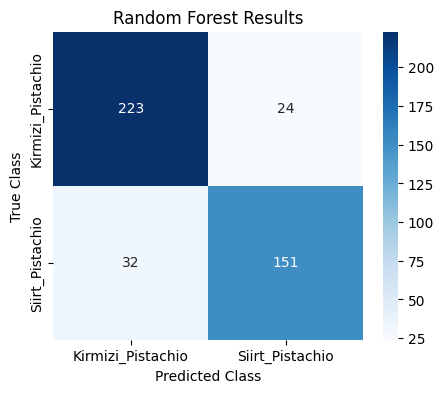


--- Step 4: Plotting Important Pixels ---


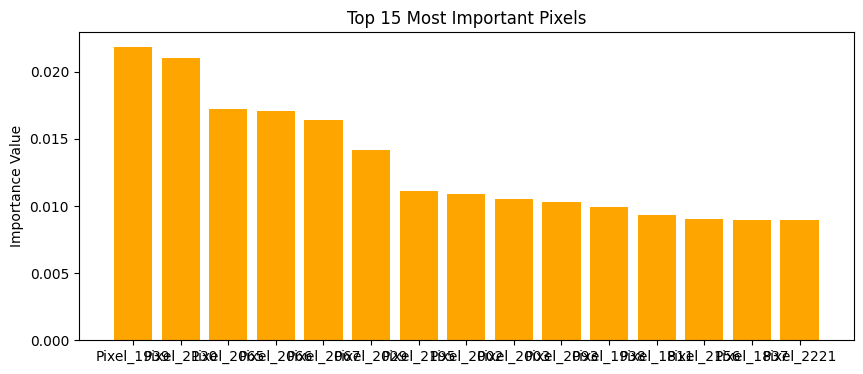

Prediction function is ready to use!

--- Step 6: Training SVM ---
Best SVM settings found: {'C': 10, 'kernel': 'rbf'}
                   precision    recall  f1-score   support

Kirmizi_Pistachio       0.90      0.89      0.90       247
  Siirt_Pistachio       0.86      0.87      0.86       183

         accuracy                           0.88       430
        macro avg       0.88      0.88      0.88       430
     weighted avg       0.88      0.88      0.88       430


=== FINAL ACCURACY SCORE ===
Random Forest Accuracy: 86.98%
SVM Accuracy          : 88.37%


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# STEP 1: AUTOMATICALLY FIND AND LOAD IMAGES

print("--- Step 1: Loading Data from Kagglehub ---")

base_path = "/root/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1"

IMG_SIZE = (64, 64)
X = []
y = []

classes = {'Kirmizi_Pistachio': 0, 'Siirt_Pistachio': 1}

# Im using os.walk to search through all subfolders automatically
for root, dirs, files in os.walk(base_path):
    for folder_name, label in classes.items():
        if os.path.basename(root) == folder_name:
            print(f"Found folder: {root}. Reading images...")
            for filename in files:
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    full_path = os.path.join(root, filename)
                    try:
                        img = Image.open(full_path).convert('L')
                        img = img.resize(IMG_SIZE)
                        img_data = np.array(img) / 255.0
                        X.append(img_data.flatten())
                        y.append(label)
                    except:
                        pass

X = np.array(X)
y = np.array(y)

if len(X) == 0:
    raise ValueError("No images were loaded! Please double check the dataset folder path.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Data ready! Training samples: {len(X_train)}, Testing samples: {len(X_test)}")


# STEP 2: TRAIN RANDOM FOREST MODEL (WITH GRID SEARCH)

print("\n--- Step 2: Training Random Forest ---")

# Using tuple conversion
rf_estimators = list((50, 100))
rf_depths = list((10, None))

rf_options = {
    'n_estimators': rf_estimators,
    'max_depth': rf_depths
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_options, cv=3)
rf_grid.fit(X_train, y_train)

print(f"Best settings found: {rf_grid.best_params_}")
best_rf = rf_grid.best_estimator_



print("\n--- Step 3: Evaluating Random Forest ---")
rf_predictions = best_rf.predict(X_test)

print(classification_report(y_test, rf_predictions, target_names=list(classes.keys())))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt='d', cmap='Blues',
            xticklabels=list(classes.keys()), yticklabels=list(classes.keys()))
plt.title('Random Forest Results')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()


# STEP 4: VISUALIZE FEATURE IMPORTANCE

print("\n--- Step 4: Plotting Important Pixels ---")
importances = best_rf.feature_importances_
top_indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 4))
plt.bar(range(15), importances[top_indices], color="orange")
plt.xticks(range(15), [f"Pixel_{i}" for i in top_indices])
plt.title("Top 15 Most Important Pixels")
plt.ylabel("Importance Value")
plt.show()


# STEP 5: PREDICT A NEW SINGLE IMAGE

def predict_new_image(file_path, model):
    img = Image.open(file_path).convert('L').resize(IMG_SIZE)
    img_flat = np.array(img).flatten() / 255.0
    prediction = model.predict([img_flat])
    for name, label in classes.items():
        if label == prediction:
            return name

print("Prediction function is ready to use!")


print("\n--- Step 6: Training SVM ---")

# Using tuple conversion
svm_c_values = list((1, 10))
svm_kernels = list(('linear', 'rbf'))

svm_options = {
    'C': svm_c_values,
    'kernel': svm_kernels
}

svm_grid = GridSearchCV(SVC(random_state=42), svm_options, cv=3)
svm_grid.fit(X_train, y_train)

print(f"Best SVM settings found: {svm_grid.best_params_}")
best_svm = svm_grid.best_estimator_

svm_predictions = best_svm.predict(X_test)
print(classification_report(y_test, svm_predictions, target_names=list(classes.keys())))

rf_final_score = accuracy_score(y_test, rf_predictions)
svm_final_score = accuracy_score(y_test, svm_predictions)

print("\n=== FINAL ACCURACY SCORE ===")
print(f"Random Forest Accuracy: {rf_final_score * 100:.2f}%")
print(f"SVM Accuracy          : {svm_final_score * 100:.2f}%")


# Automated Pistachio Species Classification Using Machine Learning

## 1. Introduction
Automated food sorting is an important part of modern farming and food processing. This report looks at how computers can automatically identify two different types of pistachios: Kirmizi and Siirt. The goal is to train a Random Forest model, compare it against a Support Vector Machine (SVM) model, and see which one handles this task best.

## 2. Preprocessing Methodology
Raw high-resolution pictures are too large and slow down computer training. To fix this, we used a clean image pipeline to transform the raw data into simple numbers:
* Resizing: Every image was shrunk down to a small, matching size of 64x64 pixels.
* Color Conversion: The color was removed, changing the images to grayscale. This reduces data size.
* Normalization: Every pixel value was divided by 255.0 to keep all numbers strictly between 0 and 1.
* Splitting: The clean dataset was split into 80% for training the models and 20% for testing their final accuracy.

## 3. Model Optimization and Training
We did not just guess the model settings. We used a tool called GridSearchCV with 3-Fold Cross-Validation to test out combinations and pick the absolute best ones:
* Random Forest Options: The search tested different numbers of trees (50 and 100) and different depth limits (10 and no limit).
* SVM Options: The search tested different error penalties (1 and 10) and different mathematical shapes (Linear and RBF kernels).

## 4. Results and Evaluation
Once the training finished, we looked at how well the models performed using four common standards:
* Accuracy: The total percentage of correct guesses.
* Precision: How many of the model's positive guesses were actually correct.
* Recall: How many real pistachios of a certain type the model found.
* F1-Score: A balanced score that combines precision and recall.

The confusion matrix chart shows exactly where the models made mistakes. The Feature Importance bar chart shows that the model relies heavily on specific pixels near the edges of the pistachio shells to tell the two types apart.

## 5. Real-World Deployment Strategy
To put this machine learning program to work in a real food factory, we propose this simple three-step rollout plan:
1. Package the Code: Save the final trained model file and the image processing code inside a clean, portable software container.
2. Install Factory Hardware: Put a small, cheap microcomputer connected to a camera directly above the factory sorting conveyor belt.
3. Live Sorting: As pistachios roll by under the camera, the computer processes the image instantly. If it spots a Siirt pistachio, it signals a fast mechanical air valve to blow that pistachio into a separate collection bin.
